# Multi-area ProcessModel to governed DEXPI engineering packages

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/dexpi_engineering_processmodel.ipynb)

This notebook builds a two-area `ProcessModel`, runs the integrated simulation, creates one `EngineeringProject` and DEXPI exchange package per `ProcessSystem` area, and compares calculated equipment design, safeguards, PSV screening and unresolved engineering inputs.

DEXPI remains an area/document exchange. Shared inter-area streams retain their NeqSim tags for reconciliation.

## 1. Load workspace NeqSim classes

In [1]:
import os
import subprocess
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = [Path(env_root).resolve()] if env_root else []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    return None


PROJECT_ROOT = find_neqsim_project_root()
if PROJECT_ROOT is None:
    # Colab/external fallback: clone and compile the current public source tree.
    PROJECT_ROOT = Path("/content/neqsim") if Path("/content").exists() else Path.cwd() / "neqsim-workspace"
    if not (PROJECT_ROOT / "pom.xml").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/equinor/neqsim.git", str(PROJECT_ROOT)],
            check=True,
        )

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes

needs_compile = not (PROJECT_ROOT / "target" / "classes").exists()
ns = neqsim_classes(
    neqsim_init(project_root=PROJECT_ROOT, recompile=needs_compile, verbose=False)
)
JClass = ns.JClass
print(f"NeqSim workspace loaded from {PROJECT_ROOT}")

All NeqSim classes imported OK
NeqSim workspace loaded from /workspace/scratch/0f75633c511c/neqsim


In [2]:
import json
import shutil
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
ProcessModel = JClass("neqsim.process.processmodel.ProcessModel")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
AdiabaticPipe = JClass("neqsim.process.equipment.pipeline.AdiabaticPipe")
DesignConditions = JClass("neqsim.process.mechanicaldesign.DesignConditions")
EngineeringBuilder = JClass("neqsim.process.engineering.NorsokOffshoreEngineeringBuilder")
EngineeringExporter = JClass("neqsim.process.engineering.dexpi.DexpiEngineeringExporter")
Paths = JClass("java.nio.file.Paths")

OUTPUT_DIR = PROJECT_ROOT / "build" / "notebook-output" / "dexpi-engineering-processmodel"
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)
print(f"Outputs: {OUTPUT_DIR}")

Outputs: /workspace/scratch/0f75633c511c/neqsim/build/notebook-output/dexpi-engineering-processmodel


## 2. Build and run a connected multi-area ProcessModel

In [3]:
fluid = SystemSrkEos(298.15, 55.0)
for component, amount in [("methane", 0.88), ("ethane", 0.07), ("propane", 0.03), ("CO2", 0.02)]:
    fluid.addComponent(component, amount)
fluid.setMixingRule("classic")

# Area 1: inlet separation
feed = Stream("10-FEED-001", fluid)
feed.setFlowRate(0.60, "MSm3/day")
inlet_separator = Separator("10-VG-001", feed)
inlet_separator.setDesignConditions(
    DesignConditions().setDesignPressure(75.0).setReliefSetPressure(72.0)
    .setMaxDesignTemperature(80.0).setMinDesignTemperature(-46.0)
)
separation = ProcessSystem()
separation.setName("inlet-separation")
separation.add(feed)
separation.add(inlet_separator)
separation.run()

# Area 2: compression and export, consuming the shared area-1 outlet stream
export_compressor = Compressor("20-KA-001", inlet_separator.getGasOutStream())
export_compressor.setOutletPressure(110.0, "bara")
export_compressor.setDesignConditions(
    DesignConditions().setDesignPressure(130.0).setMaxDesignTemperature(160.0)
)
export_pipeline = AdiabaticPipe("20-PL-001", export_compressor.getOutletStream())
export_pipeline.setLength(2500.0)
export_pipeline.setDiameter(0.35)
export_pipeline.setWallThickness(0.014)
export_pipeline.setDesignPressure(130.0, "bara")
export_pipeline.setDesignTemperature(130.0)
export_pipeline.setMaterialGrade("A106-B")
export_pipeline.setDesignConditions(
    DesignConditions().setDesignPressure(130.0).setMaxDesignTemperature(130.0)
    .setMinDesignTemperature(-46.0).setConstructionMaterial("A106-B carbon steel")
)
compression = ProcessSystem()
compression.setName("compression-export")
compression.add(export_compressor)
compression.add(export_pipeline)
compression.run()

plant = ProcessModel()
plant.add("inlet-separation", separation)
plant.add("compression-export", compression)
plant.run()
print("Areas:", list(plant.getProcessSystemNames()))
print("Export pressure: %.2f bara" % export_pipeline.getOutletStream().getPressure("bara"))

Areas: ['inlet-separation', 'compression-export']
Export pressure: 109.98 bara


## 3. Generate and export one governed project per area

In [4]:
area_projects = EngineeringBuilder.fromProcessModel("Integrated facility", plant, True)
area_data = {}
area_files = {}
for project in area_projects:
    area = str(project.getProcessSystem().getName())
    target = OUTPUT_DIR / area
    files = EngineeringExporter.export(project, Paths.get(str(target)))
    area_files[area] = files
    area_data[area] = {
        "manifest": json.loads(Path(str(files.getManifestFile().toString())).read_text()),
        "calculations": json.loads(Path(str(files.getCalculationsFile().toString())).read_text()),
        "cause_effect": json.loads(Path(str(files.getCauseAndEffectFile().toString())).read_text()),
    }

package_table = pd.DataFrame([
    {
        "Area": area,
        "Equipment calculations": len(data["calculations"]["equipmentMechanicalDesign"]),
        "Requirements": len(data["manifest"]["requirements"]),
        "Trip envelopes": len(data["calculations"]["tripSettingEnvelopes"]),
        "PSV studies": len(data["calculations"]["overpressureAndPsvSizing"]),
        "Open gaps": len(data["calculations"]["unresolvedEngineering"]),
        "DEXPI exists": Path(str(area_files[area].getDexpiFile().toString())).exists(),
    }
    for area, data in area_data.items()
])
display(package_table)

                 Area  Equipment calculations  Requirements  Trip envelopes  PSV studies  Open gaps  DEXPI exists
0    inlet-separation                       1             8               4            1          5          True
1  compression-export                       2             8               3            0          5          True


## 4. Equipment design coverage

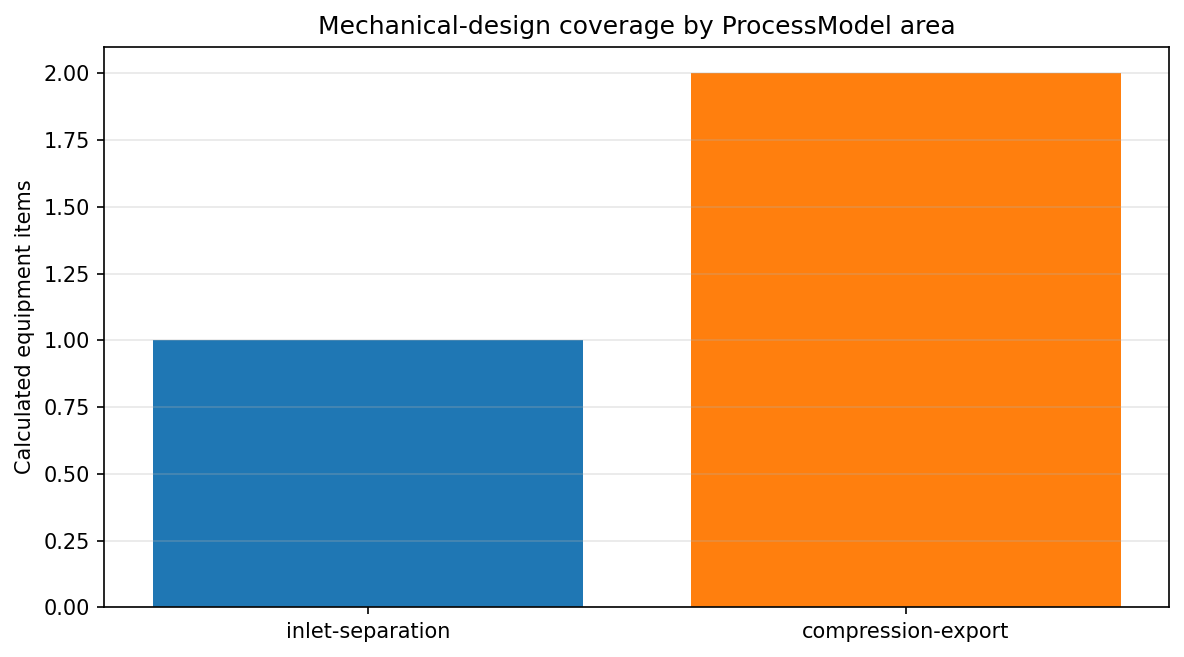

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(package_table["Area"], package_table["Equipment calculations"], color=["tab:blue", "tab:orange"])
ax.set_ylabel("Calculated equipment items")
ax.set_title("Mechanical-design coverage by ProcessModel area")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "area_equipment_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion.** Equipment calculations follow the area boundary and the equipment actually modeled in each `ProcessSystem`. This keeps documents manageable and avoids duplicating items. Shared-stream tag reconciliation and project document numbering remain document-control responsibilities.

## 5. Controls and safeguards by area

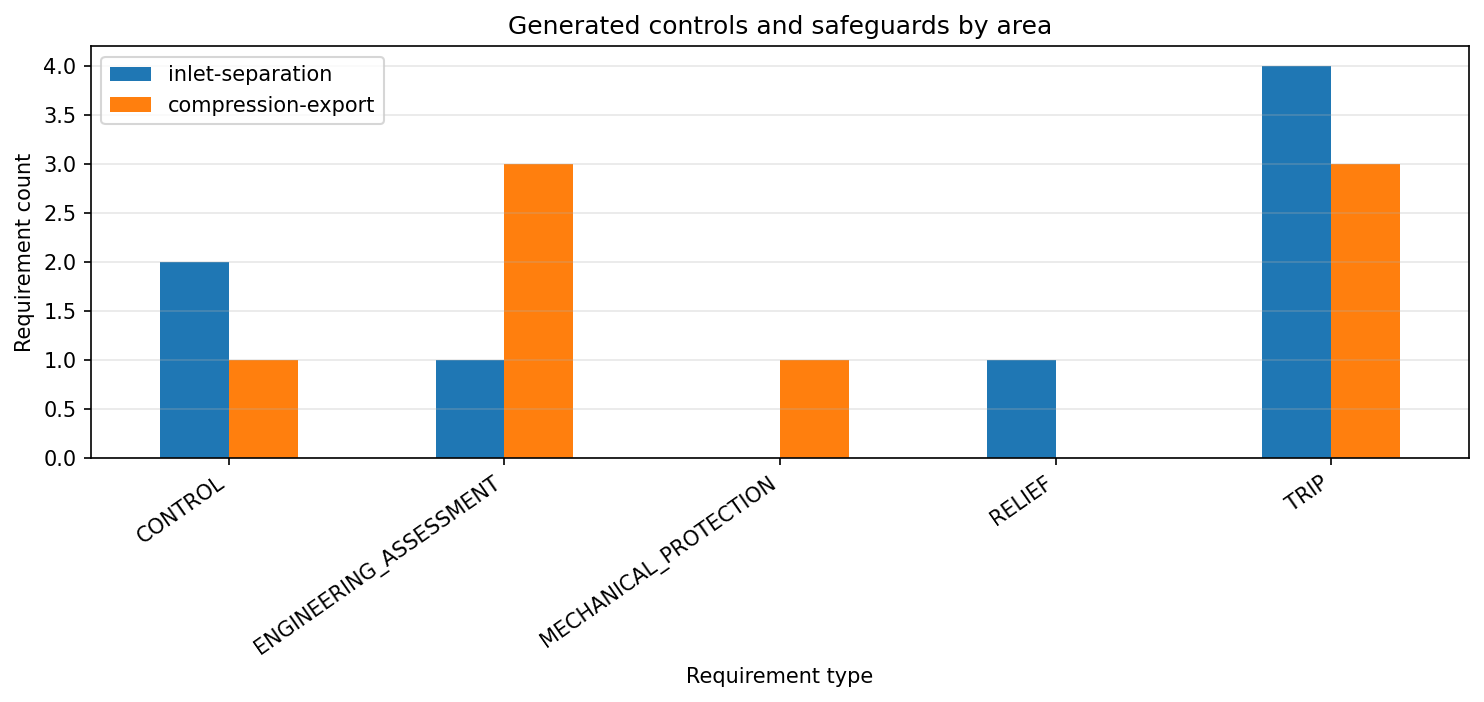

In [6]:
requirement_types = {}
for area, data in area_data.items():
    requirement_types[area] = Counter(item["type"] for item in data["manifest"]["requirements"])
all_types = sorted(set().union(*[set(values) for values in requirement_types.values()]))
req_df = pd.DataFrame({area: [counts.get(kind, 0) for kind in all_types] for area, counts in requirement_types.items()}, index=all_types)

ax = req_df.plot(kind="bar", figsize=(10, 4.8))
ax.set_xlabel("Requirement type")
ax.set_ylabel("Requirement count")
ax.set_title("Generated controls and safeguards by area")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "area_requirement_types.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion.** Requirement types differ because the rule pack responds to actual equipment classes. Separation receives level, pressure and relief functions; compression receives antisurge, machinery protection, isolation and trip functions. The rules propose functions, not final SIL/voting/set points.

## 6. Data gaps remain explicit

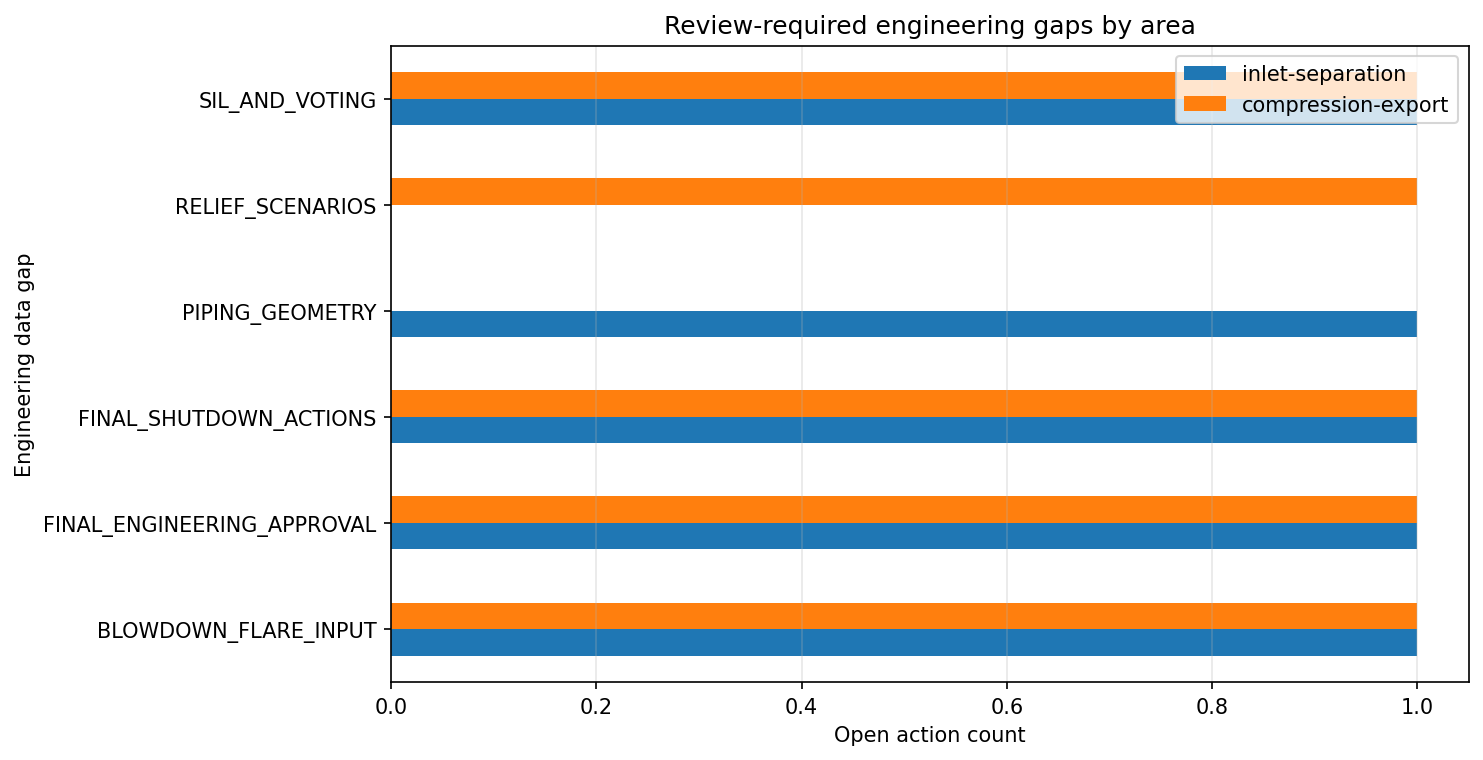

In [7]:
gap_counts = {
    area: Counter(gap["code"] for gap in data["calculations"]["unresolvedEngineering"])
    for area, data in area_data.items()
}
all_gaps = sorted(set().union(*[set(values) for values in gap_counts.values()]))
gap_df = pd.DataFrame({area: [counts.get(code, 0) for code in all_gaps] for area, counts in gap_counts.items()}, index=all_gaps)

ax = gap_df.plot(kind="barh", figsize=(10, 5.2))
ax.set_xlabel("Open action count")
ax.set_ylabel("Engineering data gap")
ax.set_title("Review-required engineering gaps by area")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "area_engineering_gaps.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion.** Area packages expose different missing inputs. For example, an area without explicit pipe geometry cannot run P-002 sizing, and an area without a reviewed blowdown/flare data source cannot produce design-grade transient results. Closing a gap requires project evidence, not a generic default.

## 7. Governance and standards traceability

In [8]:
for area, data in area_data.items():
    print()
    print(area)
    print("  status:", data["calculations"]["documentStatus"])
    print("  fitness for construction:", data["calculations"]["governance"]["fitnessForConstruction"])
    print("  standards:", ", ".join(item["code"] for item in data["manifest"]["designBasis"]["standards"][:8]), "...")
    for gap in data["calculations"]["unresolvedEngineering"]:
        print("  -", gap["code"], "=>", gap["requiredAction"])


inlet-separation
  status: CALCULATED_AND_PROPOSED_REVIEW_REQUIRED
  fitness for construction: False
  standards: DEXPI, ISO 10628-1/2, IEC 62424, IEC 61511, ISO 10418, API 521, API 520 Part I, ASME B31.3 ...
  - BLOWDOWN_FLARE_INPUT => Add vessel inventory, fluid, BDV/orifice, header, fire and flare evidence.
  - PIPING_GEOMETRY => Add pipe/pipeline equipment and line-list/design conditions for NORSOK P-002 and mechanical sizing.
  - SIL_AND_VOTING => Import approved HAZOP/LOPA/SIL-assessment and SRS references before selecting voting architecture.
  - FINAL_SHUTDOWN_ACTIONS => Confirm isolation boundaries, sequencing, delays, permissives, reset and restart in HAZOP/LOPA and the SRS.
  - FINAL_ENGINEERING_APPROVAL => Complete discipline checking, vendor verification, HAZOP/LOPA and accountable approval.

compression-export
  status: CALCULATED_AND_PROPOSED_REVIEW_REQUIRED
  fitness for construction: False
  standards: DEXPI, ISO 10628-1/2, IEC 62424, IEC 61511, ISO 10418, API 521, AP

## Summary

`fromProcessModel(...)` makes the same engineering-generation workflow available to integrated facilities. Each area gets DEXPI XML, a governed manifest, simulation-backed calculations, cause/effect proposals and relevant datasets. These are concept/pre-FEED handoffs until discipline review, vendor verification, HAZOP/LOPA, SRS approval and project DEXPI validation are complete.